# Lab 6

In [191]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Questions

#### 1. Create the following data set for Experience and Salary in CSV. Applying SLR, explore the relationship between salary and experience with experience in x-axis and salary in y axis.
- Check for various values of beta (slope) = 0.1, 1.5, and 0.8 with a fixed value of intercept i.e b = 1.1. Plot the graph between beta and mean squared error (MSE) for each case.
- Try with beta between 0 to 1.5 with an increment of 0.01 keeping b (intercept) as constant and plot the graph between beta and mean squared error (MSE).
- Try with different values of intercept for slope beta between 0 to 1.5 with an increment of 0.01. Plot the graph between 
beta and mean squared error (MSE).
- Use `scikit-learn` and compare the results of MSE.

In [192]:
data = {
    "salary": [1.7, 2.4, 2.3, 3.1, 3.7, 4.2, 4.4, 6.1, 5.4, 5.7, 6.4, 6.2],
    "experience": [1.2, 1.5, 1.9, 2.2, 2.4, 2.5, 2.8, 3.1, 3.3, 3.7, 4.2, 4.4]
}

df = pd.DataFrame(data)

df.to_csv("salary.csv", index=False)

df.head()

,salary,experience
0,1.7,1.2
1,2.4,1.5
2,2.3,1.9
3,3.1,2.2
4,3.7,2.4


In [193]:
X = df["experience"]
y = df["salary"]

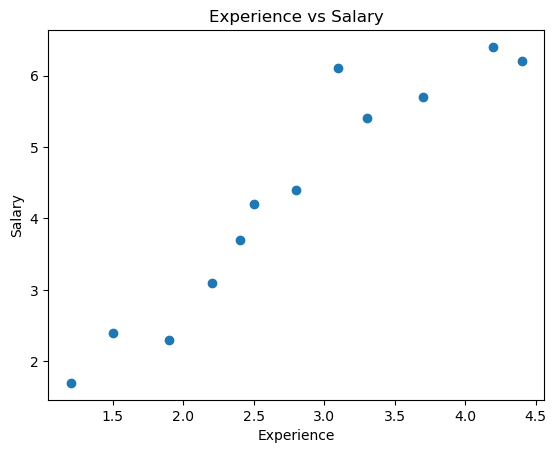

In [194]:
plt.scatter(X, y)

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")

plt.show()

In [195]:
# beta = 0.1, 1.5, 0.8 with fixed intercept b = 1.1

betas = [0.1, 1.5, 0.8]
b = 1.1

mse_values = []

for beta in betas:
    y_pred = b + beta * X
    mse = np.mean((y - y_pred) ** 2)

    mse_values.append(mse)

    print(f"Beta: {beta}, MSE: {mse}")

Beta: 0.1, MSE: 10.81115
Beta: 1.5, MSE: 1.1404166666666662
Beta: 0.8, MSE: 1.762599999999999


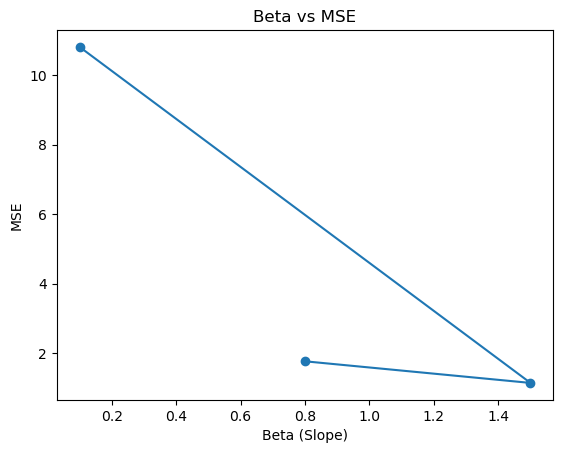

In [196]:
plt.plot(betas, mse_values, marker="o")

plt.xlabel("Beta (Slope)")
plt.ylabel("MSE")
plt.title("Beta vs MSE")

plt.show()

In [197]:
# beta from 0 to 1.5 with increment 0.01

betas = np.arange(0, 1.51, 0.01)

mse_values = []

for beta in betas:
    y_pred = 1.1 + beta * X
    mse = np.mean((y - y_pred) ** 2)
    mse_values.append(mse)

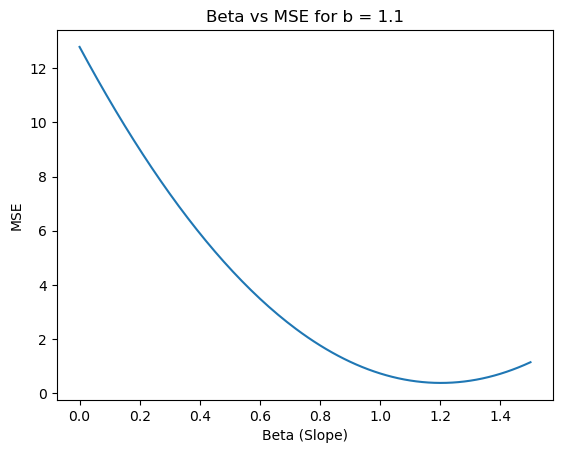

In [198]:
plt.plot(betas, mse_values)

plt.xlabel("Beta (Slope)")
plt.ylabel("MSE")
plt.title("Beta vs MSE for b = 1.1")

plt.show()

In [199]:
min_idx = np.argmin(mse_values)

print(f"Best beta: {betas[min_idx]}")
print(f"Minimum MSE: {mse_values[min_idx]}")

Best beta: 1.2
Minimum MSE: 0.3752666666666666


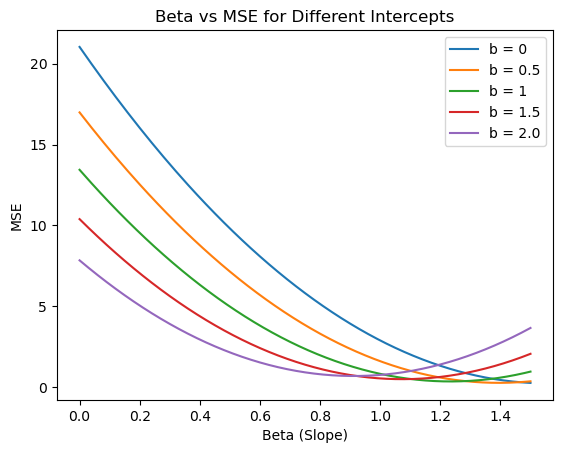

In [200]:
# different intercept values

intercepts = [0, 0.5, 1, 1.5, 2.0]
betas = np.arange(0, 1.51, 0.01)

for b in intercepts:
    mse_values = []

    for beta in betas:
        y_pred = b + beta * X
        mse = np.mean((y - y_pred) ** 2)
        mse_values.append(mse)

    plt.plot(betas, mse_values, label=f"b = {str(b)}")

plt.xlabel("Beta (Slope)")
plt.ylabel("MSE")
plt.title("Beta vs MSE for Different Intercepts")
plt.legend()

plt.show()

In [201]:
# use sklearn to compare

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = df[['experience']]
y = df[['salary']]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print(f"Slope: {model.coef_[0]}")
print(f"Intercept: {model.intercept_}")
print(f"MSE: {mean_squared_error(y, y_pred)}")

Slope: [1.56709829]
Intercept: [-0.03563861]
MSE: 0.23366710810280558


#### 2. Apply Stochastic Gradient Descent for the afore-mentioned dataset, and arrive at different values of B0, B1 and error for 60 iterations of 5 epochs.
- Plot the graph of log loss/error versus iteration.
- Use the scikit learn and arrive at the results of B0, B1 and error, for 60 iterations of 5 epochs.
- Plot the graph between beta (X-axis) and log loss/error (Y-axis) using scikit learn and your approach separately.
- Plot the separate graph of –log(x) ( y=1 case) and –log(1-x) (y=0 case) and also draw the combined graph of both cases.

In [202]:
X = df["experience"].values
y = df["salary"].values

In [203]:
np.random.seed(67)

b0 = 0.0
b1 = 0.0

lr = 0.01
iters = 60
epochs = 5

history = []

count = 0

for epoch in range(epochs):
    for i in range(iters):
        idx = np.random.randint(0, len(X))

        xi = X[idx]
        yi = y[idx]

        y_pred = b0 + b1 * xi
        err = yi - y_pred

        b0 = b0 + 2 * lr * err
        b1 = b1 + 2 * lr * err * xi

        y_all_pred = b0 + b1 * X
        mse = np.mean((y - y_all_pred) ** 2)

        count += 1

        history.append([
            epoch + 1,
            i + 1,
            count,
            b0,
            b1,
            mse
        ])

In [204]:
manual_df = pd.DataFrame(
    history,
    columns=['epoch', 'iteration', 'total iterations', 'b0', 'b1', 'error']
)

manual_df.head()

,epoch,iteration,total iterations,b0,b1,error
0,1,1,1,0.062000,0.136400,17.070149
1,1,2,2,0.137940,0.326250,12.310894
2,1,3,3,0.235776,0.737162,4.983393
3,1,4,4,0.278203,0.843228,3.580524
4,1,5,5,0.342358,1.042111,1.648295


In [205]:
print(f"B0: {b0}")
print(f"B1: {b1}")
print(f"MSE: {manual_df['error'].iloc[-1]}")

B0: 0.2472913313858277
B1: 1.4453727159054661
MSE: 0.2505520123845701


In [206]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

np.random.seed(67)

model = SGDRegressor(
    loss="squared_error",
    learning_rate="constant",
    eta0=0.01,
    penalty=None,
    fit_intercept=True,
    random_state=67
)

history_sk = []
count = 0

for epoch in range(epochs):
    for i in range(iters):
        idx = np.random.randint(0, len(X))

        X_sample = X[idx].reshape(1, -1)
        y_sample = np.array([y[idx]])

        model.partial_fit(X_sample, y_sample)

        y_all_pred = model.predict(X.reshape(-1, 1))

        mse = mean_squared_error(y, y_all_pred)

        b0_sk = model.intercept_[0]
        b1_sk = model.coef_[0]

        count += 1

        history_sk.append([
            epoch + 1,
            i + 1,
            count,
            b0_sk,
            b1_sk,
            mse
        ])

sk_df = pd.DataFrame(
    history_sk,
    columns=["epoch", "iteration", "total iterations", "b0", "b1", "error"]
)

sk_df.head()

,epoch,iteration,total iterations,b0,b1,error
0,1,1,1,0.031000,0.068200,19.003255
1,1,2,2,0.070985,0.168162,16.246808
2,1,3,3,0.127212,0.404317,10.837856
3,1,4,4,0.157832,0.480867,9.253403
4,1,5,5,0.202347,0.618863,6.772810


In [207]:
print(f"B0: {model.intercept_[0]}")
print(f"B1: {model.coef_[0]}")
print(f"MSE: {sk_df['error'].iloc[-1]}")

B0: 0.3301852518231909
B1: 1.4382312255612968
MSE: 0.24942834225067023


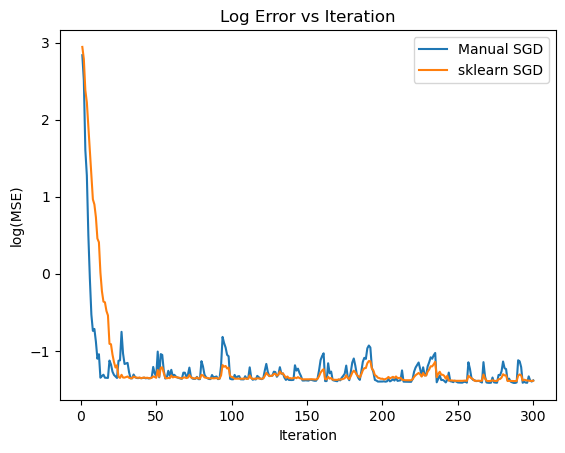

In [208]:
plt.plot(
    manual_df["total iterations"],
    np.log(manual_df["error"]),
    label="Manual SGD"
)

plt.plot(
    sk_df["total iterations"],
    np.log(sk_df["error"]),
    label="sklearn SGD"
)

plt.xlabel("Iteration")
plt.ylabel("log(MSE)")
plt.title("Log Error vs Iteration")

plt.legend()
plt.show()

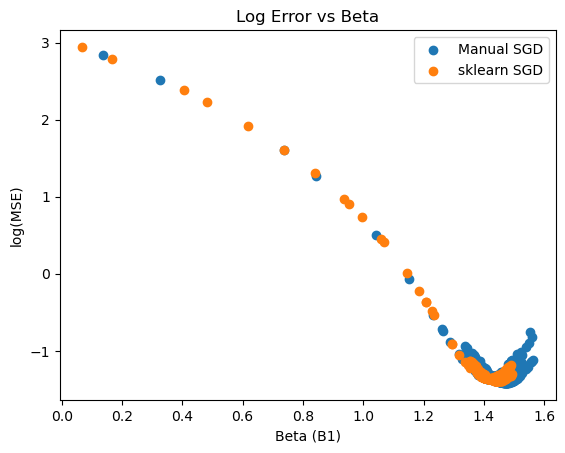

In [209]:
plt.scatter(
    manual_df["b1"],
    np.log(manual_df["error"]),
    label="Manual SGD"
)

plt.scatter(
    sk_df["b1"],
    np.log(sk_df["error"]),
    label="sklearn SGD"
)

plt.xlabel("Beta (B1)")
plt.ylabel("log(MSE)")
plt.title("Log Error vs Beta")

plt.legend()
plt.show()

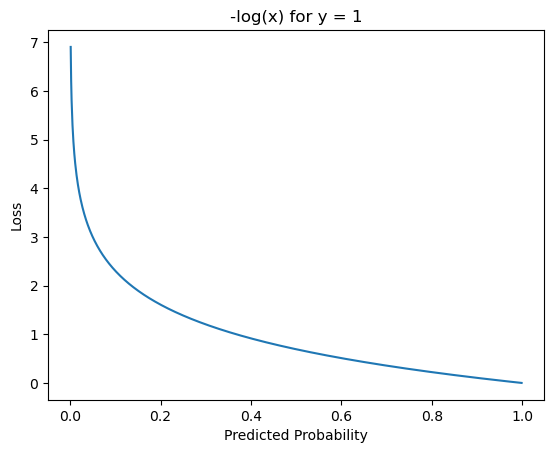

In [210]:
x = np.linspace(0.001, 0.999, 1000)

y1 = -np.log(x)

plt.plot(x, y1)

plt.xlabel("Predicted Probability")
plt.ylabel("Loss")
plt.title("-log(x) for y = 1")

plt.show()

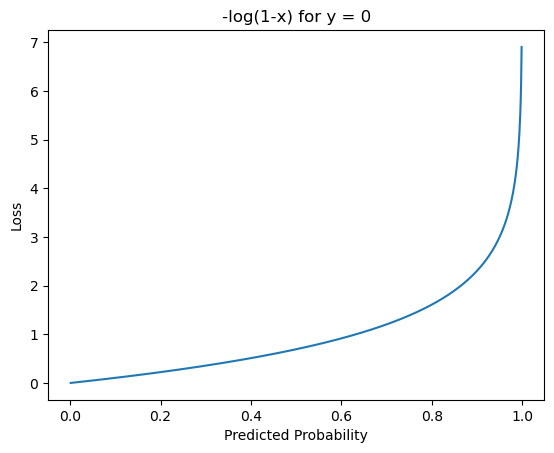

In [211]:
y0 = -np.log(1 - x)

plt.plot(x, y0)

plt.xlabel("Predicted Probability")
plt.ylabel("Loss")
plt.title("-log(1-x) for y = 0")

plt.show()

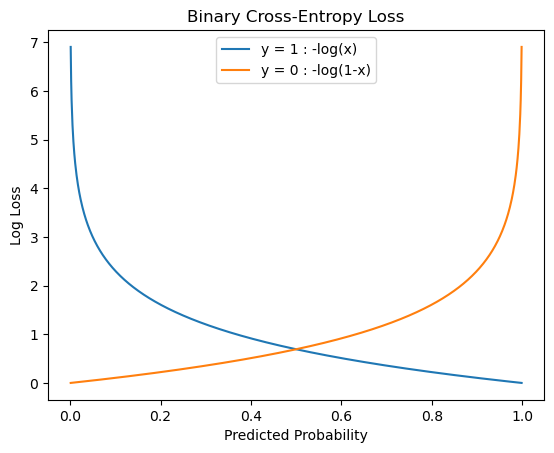

In [212]:
x = np.linspace(0.001, 0.999, 1000)

plt.plot(x, -np.log(x), label="y = 1 : -log(x)")
plt.plot(x, -np.log(1 - x), label="y = 0 : -log(1-x)")

plt.xlabel("Predicted Probability")
plt.ylabel("Log Loss")
plt.title("Binary Cross-Entropy Loss")

plt.legend()
plt.show()

#### 3. Consider positive and negative slope dataset given below. Apply simple linear regression with gradient descent and illustrate the difference between slope values for both cases at different iterations. Plot the graph of slope(x-axis) vs MSE (y-axis) for both case separately.
- `x = np.array([1, 2, 4, 3, 5])`
- `y = np.array([1, 3, 3, 2, 5])`  Positive slope
 
- `x = np.array([1, 2, 3, 4, 5])`
- `y = np.array([10, 8, 6, 4, 2])`  Negative slope

In [213]:
# positive slope
 
x = np.array([1, 2, 4, 3, 5])
y = np.array([1, 3, 3, 2, 5])

b0 = 0.0
b1 = 0.0

lr = 0.01
iters = 100

history_pos = []
n = len(x)

for i in range(iters):
    y_pred = b0 + b1 * x

    err = y_pred - y

    db0 = (2 / n) * np.sum(err)
    db1 = (2 / n) * np.sum(err * x)

    b0 = b0 - lr * db0
    b1 = b1 - lr * db1

    y_pred = b0 + b1 * x
    mse = np.mean((y - y_pred) ** 2)

    history_pos.append([
        i + 1,
        b0,
        b1,
        mse
    ])

pos_df = pd.DataFrame(
    history_pos,
    columns=["iteration", "b0", "b1", "MSE"]
)

pos_df.head()

,iteration,b0,b1,MSE
0,1,0.056000,0.200000,5.796736
1,2,0.098880,0.352640,3.580368
2,3,0.131744,0.469126,2.288765
3,4,0.156962,0.558014,1.536069
4,5,0.176341,0.625833,1.097421


In [214]:
print(f"B0: {b0}")
print(f"B1: {b1}")
print(f"MSE: {mse}")``

SyntaxError: invalid syntax (2246963140.py, line 3)

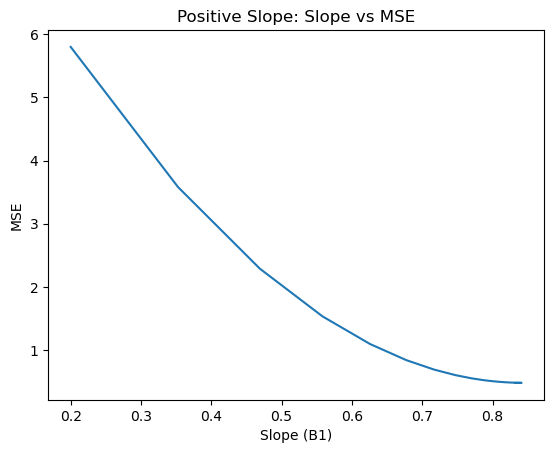

In [ ]:
plt.plot(pos_df["b1"], pos_df["MSE"])

plt.xlabel("Slope (B1)")
plt.ylabel("MSE")
plt.title("Positive Slope: Slope vs MSE")

plt.show()

In [ ]:
# negative slope

x = np.array([1, 2, 3, 4, 5])
y = np.array([10, 8, 6, 4, 2])

b0 = 0.0
b1 = 0.0

lr = 0.01
iters = 100

history_neg = []
n = len(x)

for i in range(iters):
    y_pred = b0 + b1 * x

    err = y_pred - y

    db0 = (2 / n) * np.sum(err)
    db1 = (2 / n) * np.sum(err * x)

    b0 = b0 - lr * db0
    b1 = b1 - lr * db1

    y_pred = b0 + b1 * x
    mse = np.mean((y - y_pred) ** 2)

    history_neg.append([
        i + 1,
        b0,
        b1,
        mse
    ])

neg_df = pd.DataFrame(
    history_neg,
    columns=["iteration", "b0", "b1", "MSE"]
)

neg_df.head()

,iteration,b0,b1,MSE
0,1,0.120000,0.280000,35.798400
1,2,0.220800,0.491200,30.950346
2,3,0.306912,0.649888,28.057036
3,4,0.381780,0.768498,26.303313
4,5,0.448035,0.856522,25.214143


In [ ]:
print(f"B0: {b0}")
print(f"B1: {b1}")
print(f"MSE: {mse}")

B0: 3.6900944183066526
B1: 0.3017105963620532
MSE: 12.5691327472067


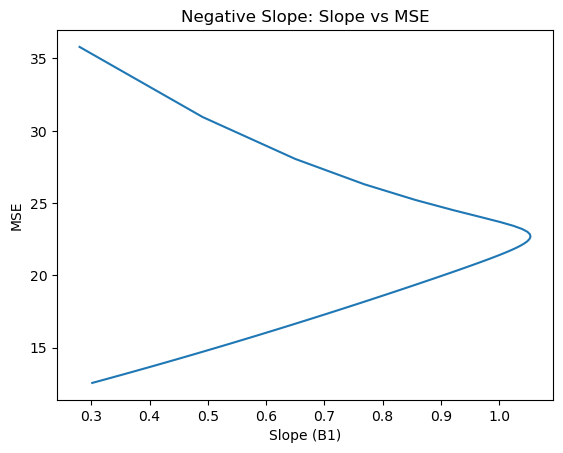

In [ ]:
plt.plot(neg_df["b1"], neg_df["MSE"])

plt.xlabel("Slope (B1)")
plt.ylabel("MSE")
plt.title("Negative Slope: Slope vs MSE")

plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Iteration": pos_df["iteration"],
    "Positive Slope": pos_df["b1"],
    "Negative Slope": neg_df["b1"]
})

comparison.head()

,Iteration,Positive Slope,Negative Slope
0,1,0.200000,0.280000
1,2,0.352640,0.491200
2,3,0.469126,0.649888
3,4,0.558014,0.768498
4,5,0.625833,0.856522


#### 4. Consider positive and negative slope dataset given below. Apply  logistic regression with gradient descent and illustrate the difference between slope values for both cases at different iterations. Plot the graph of slope(x-axis) vs  log-loss (y-axis) for both case separately.
 
- `x = np.array([1, 2, 3, 4, 5])` 
- `y = np.array([0, 0, 1, 1, 1])` Positive slope

- `x = np.array([1, 2, 3, 4, 5])` 
- `y = np.array([1, 1, 0, 0, 0])` Negative slope

In [ ]:
# positive slope

x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([0, 0, 1, 1, 1], dtype=float)

b0 = 0.0
b1 = 0.0

lr = 0.1
iters = 100

history_pos = []
n = len(x)

for i in range(iters):
    z = b0 + b1 * x

    p = 1 / (1 + np.exp(-z))

    db0 = np.mean(p - y)
    db1 = np.mean((p - y) * x)

    b0 = b0 - lr * db0
    b1 = b1 - lr * db1

    z = b0 + b1 * x
    p = 1 / (1 + np.exp(-z))

    p = np.clip(p, 1e-15, 1 - 1e-15)

    log_loss = -np.mean(
        y * np.log(p) + (1 - y) * np.log(1 - p)
    )

    history_pos.append([
        i + 1,
        b0,
        b1,
        log_loss
    ])

pos_df = pd.DataFrame(
    history_pos,
    columns=["iteration", "b0", "b1", "log_loss"]
)

pos_df.head()

,iteration,b0,b1,log_loss
0,1,0.010000,0.090000,0.622899
1,2,0.013073,0.154815,0.586389
2,3,0.011488,0.202785,0.566081
3,4,0.006745,0.239410,0.553847
4,5,-0.000199,0.268161,0.545861


In [ ]:
print(f"B0: {b0}")
print(f"B1: {b1}")
print(f"Log Loss: {log_loss}")

B0: -1.1127419789476956
B1: 0.7222348899194608
Log Loss: 0.3847939539214676


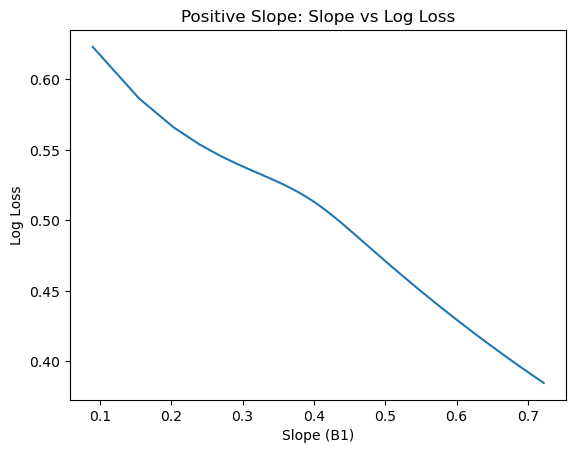

In [ ]:
plt.plot(pos_df["b1"], pos_df["log_loss"])

plt.xlabel("Slope (B1)")
plt.ylabel("Log Loss")
plt.title("Positive Slope: Slope vs Log Loss")

plt.show()

In [ ]:
# negative slope

x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([1, 1, 0, 0, 0], dtype=float)

b0 = 0.0
b1 = 0.0

lr = 0.1
iters = 100

history_neg = []
n = len(x)

for i in range(iters):
    z = b0 + b1 * x

    p = 1 / (1 + np.exp(-z))

    db0 = np.mean(p - y)
    db1 = np.mean((p - y) * x)

    b0 = b0 - lr * db0
    b1 = b1 - lr * db1

    z = b0 + b1 * x
    p = 1 / (1 + np.exp(-z))

    p = np.clip(p, 1e-15, 1 - 1e-15)

    log_loss = -np.mean(
        y * np.log(p) + (1 - y) * np.log(1 - p)
    )

    history_neg.append([
        i + 1,
        b0,
        b1,
        log_loss
    ])

neg_df = pd.DataFrame(
    history_neg,
    columns=["iteration", "b0", "b1", "log_loss"]
)

neg_df.head()

,iteration,b0,b1,log_loss
0,1,-0.010000,-0.090000,0.622899
1,2,-0.013073,-0.154815,0.586389
2,3,-0.011488,-0.202785,0.566081
3,4,-0.006745,-0.239410,0.553847
4,5,0.000199,-0.268161,0.545861


In [ ]:
print(f"B0: {b0}")
print(f"B1: {b1}")
print(f"Log Loss: {log_loss}")

B0: 1.1127419789476956
B1: -0.7222348899194609
Log Loss: 0.38479395392146754


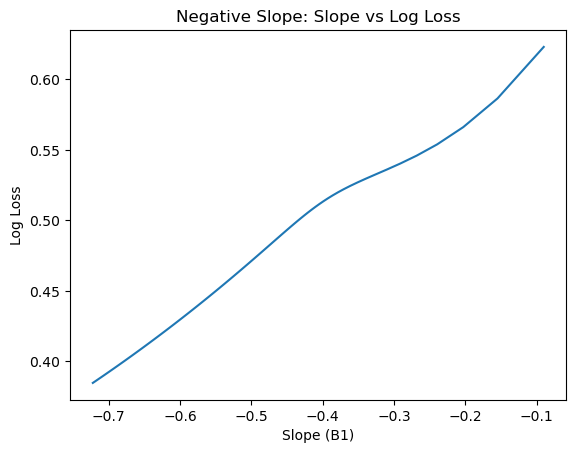

In [ ]:
plt.plot(neg_df["b1"], neg_df["log_loss"])

plt.xlabel("Slope (B1)")
plt.ylabel("Log Loss")
plt.title("Negative Slope: Slope vs Log Loss")

plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Iteration": pos_df["iteration"],
    "Positive Slope": pos_df["b1"],
    "Negative Slope": neg_df["b1"]
})

comparison.head()

,Iteration,Positive Slope,Negative Slope
0,1,0.090000,-0.090000
1,2,0.154815,-0.154815
2,3,0.202785,-0.202785
3,4,0.239410,-0.239410
4,5,0.268161,-0.268161


## Additional Questions

#### 1. Apply scikit learn model for Simple Linear Regression using SGD of the given salary.csv dataset, and arrive at different values of B0, B1 and error for varying iterations. Plot the graph of epoch (X-axis) versus error (Y-axis).

In [ ]:
df = pd.read_csv('salary.csv')
df.head()

,salary,experience
0,1.7,1.2
1,2.4,1.5
2,2.3,1.9
3,3.1,2.2
4,3.7,2.4


In [ ]:
X = df[["experience"]]
y = df["salary"]

In [ ]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

model = SGDRegressor(
    loss="squared_error",
    learning_rate="constant",
    eta0=0.01,
    penalty=None,
    random_state=42
)

In [ ]:
epochs = 100
history = []

for epoch in range(epochs):
    model.partial_fit(X, y)

    y_pred = model.predict(X)

    mse = mean_squared_error(y, y_pred)

    b0 = model.intercept_[0]
    b1 = model.coef_[0]

    history.append([
        epoch + 1,
        b0,
        b1,
        mse
    ])

result_df = pd.DataFrame(
    history,
    columns=["epoch", "b0", "b1", "MSE"]
)

result_df.head()

,epoch,b0,b1,MSE
0,1,0.140465,1.494111,0.239362
1,2,0.138999,1.494604,0.239300
2,3,0.137551,1.495091,0.239239
3,4,0.136120,1.495571,0.239179
4,5,0.134707,1.496046,0.239120


In [ ]:
print(f"B0: {b0}")
print(f"B1: {b1}")
print(f"MSE: {mse}")

B0: 0.05597762472526418
B1: 1.5224963301957328
MSE: 0.236554948507805


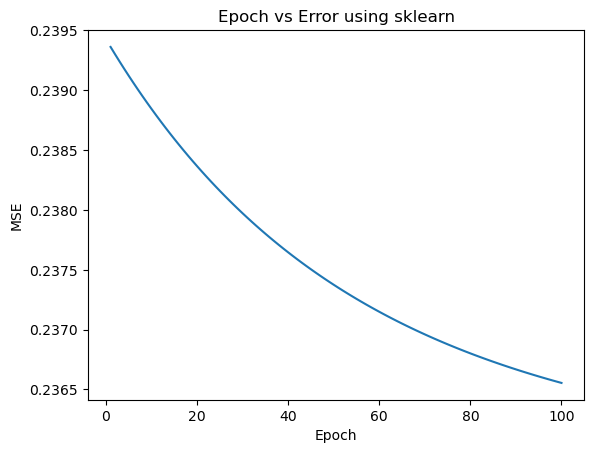

In [ ]:
plt.plot(result_df["epoch"], result_df["MSE"])

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Epoch vs Error using sklearn")

plt.show()

#### 2. Apply simple linear regression with gradient descent method for x = {1, 2, 4, 3, 5} and y = {1, 3, 3, 2, 5} and plot error (y axis) vs. iteration (x axis) for 4 epochs (20 iterations). Manually work out the values for the first epoch and verify the results in your notebook.

In [ ]:
x = np.array([1, 2, 4, 3, 5])
y = np.array([1, 3, 3, 2, 5])

b0 = 0.0
b1 = 0.0

lr = 0.01
epochs = 4

history = []

iter = 0

for epoch in range(epochs):
    for i in range(len(x)):
        y_pred = b0 + b1 * x[i]

        err = y[i] - y_pred

        b0 = b0 + 2 * lr * err
        b1 = b1 + 2 * lr * err * x[i]

        y_all_pred = b0 + b1 * x
        mse = np.mean((y - y_all_pred) ** 2)

        iter += 1

        history.append([
            epoch + 1,
            iter,
            x[i],
            y[i],
            y_pred,
            err,
            b0,
            b1,
            mse
        ])

result = pd.DataFrame(
    history,
    columns = [
        "epoch",
        "iteration",
        "x",
        "y",
        "predicted",
        "error",
        "b0",
        "b1",
        "MSE"
    ]
)

result.head()

,epoch,iteration,x,y,predicted,error,b0,b1,MSE
0,1,1,1,1,0.000000,1.000000,0.020000,0.020000,9.095200
1,1,2,2,3,0.060000,2.940000,0.078800,0.137600,6.686258
2,1,3,4,3,0.629200,2.370800,0.126216,0.327264,3.789796
3,1,4,3,2,1.108008,0.891992,0.144056,0.380784,3.122451
4,1,5,5,5,2.047973,2.952027,0.203096,0.675986,0.834457


In [ ]:
print(f"B0: {b0}")
print(f"B1: {b1}")
print(f"MSE {mse}")

B0: 0.2612881946707611
B1: 0.8677030361761322
MSE 0.49331441487425787


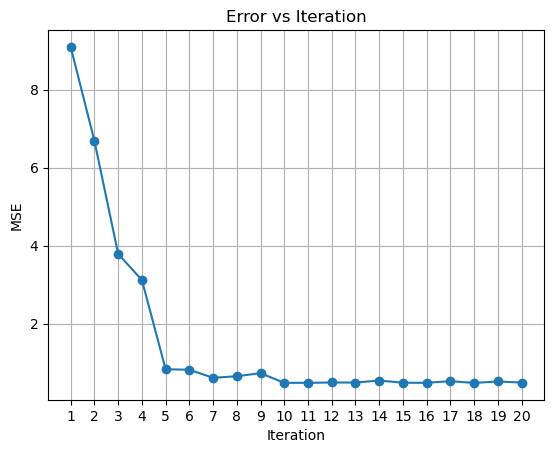

In [ ]:
plt.plot(result["iteration"], result["MSE"], marker="o")

plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Error vs Iteration")

plt.xticks(range(1, 21))
plt.grid()

plt.show()

#### 3. Apply logistic regression with gradient descent method for following data set and plot error (y axis) vs. iteration (x axis) for 4 epochs (32 iterations). Manually work out the values for first epoch and verify the results in your notebook.

In [215]:
x = np.array([1, 2, 3, 4, 5, 6, 7, 8])
y = np.array([0, 0, 0, 0, 1, 1, 1, 1])

b0 = 0.0
b1 = 0.0

lr = 0.01
epochs = 4

history = []
iter = 0

for epoch in range(epochs):
    for i in range(len(x)):
        z = b0 + b1 * x[i]

        y_pred = 1 / (1 + np.exp(-z))

        err = y_pred - y[i]

        b0 = b0 - lr * err
        b1 = b1 - lr * err * x[i]

        z_all = b0 + b1 * x
        y_all_pred = 1 / (1 + np.exp(-z_all))

        y_all_pred = np.clip(y_all_pred, 1e-15, 1 - 1e-15)

        log_loss = -np.mean(
            y * np.log(y_all_pred) +
            (1 - y) * np.log(1 - y_all_pred)
        )

        iter += 1

        history.append([
            epoch + 1,
            iter,
            x[i],
            y[i],
            y_pred,
            b0,
            b1,
            log_loss
        ])

result = pd.DataFrame(
    history,
    columns = [
        "epoch",
        "iteration",
        "x",
        "y",
        "predicted",
        "b0",
        "b1",
        "log_loss"
    ]
)

result.head()

,epoch,iteration,x,y,predicted,b0,b1,log_loss
0,1,1,1,0,0.500000,-0.005000,-0.005000,0.698258
1,1,2,2,0,0.496250,-0.009963,-0.014925,0.708961
2,1,3,3,0,0.486319,-0.014826,-0.029515,0.725952
3,1,4,4,0,0.466828,-0.019494,-0.048188,0.749802
4,1,5,5,1,0.435257,-0.013847,-0.019951,0.714700


In [216]:
print(f"B0: {b0}")
print(f"B1: {b1}")
print(f"Log loss: {log_loss}")

B0: -0.024515103579603167
B1: 0.17392331396923844
Log loss: 0.606543146434434


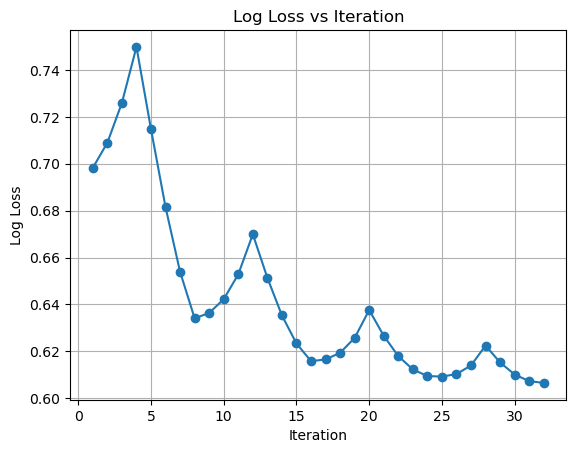

In [218]:
plt.plot(
    result["iteration"],
    result["log_loss"],
    marker="o"
)

plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.title("Log Loss vs Iteration")

plt.grid()

plt.show()